In [1]:
import pandas as pd
from functools import reduce

In [2]:
# Ruta base
path = "cleaned_data/"

# Cargar todos los dataframes
df_alcohol = pd.read_parquet(path + "df_alcohol.parquet")
df_corruption = pd.read_parquet(path + "df_corruption.parquet")
#df_homicides = pd.read_parquet(path + "df_homicides.parquet")
df_informal = pd.read_parquet(path + "df_informal.parquet")
df_mental = pd.read_parquet(path + "df_mental.parquet")
df_merged = pd.read_parquet(path + "df_merged.parquet")
df = pd.read_csv('suicides.csv')

# Verificar dimensiones
print("Alcohol:", df_alcohol.shape)
print("Corruption:", df_corruption.shape)
#print("Homicides:", df_homicides.shape)
print("Informal:", df_informal.shape)
print("Mental:", df_mental.shape)
print("Merged:", df_merged.shape)

Alcohol: (4324, 4)
Corruption: (3557, 4)
Informal: (3294, 3)
Mental: (4896, 4)
Merged: (6760, 13)


In [3]:
# Función para auditoría rápida
def audit_df(name, df):
    print(f"\n{name}")
    print("-" * 40)
    print("Shape:", df.shape)
    
    if "country" in df.columns:
        print("Unique countries:", df["country"].nunique())
    if "country_code" in df.columns:
        print("Unique country codes:", df["country_code"].nunique())
    if "year" in df.columns:
        print("Year range:", df["year"].min(), "-", df["year"].max())
        print("Unique years:", df["year"].nunique())


# Ejecutar auditoría
audit_df("Alcohol", df_alcohol)
audit_df("Corruption", df_corruption)
#audit_df("Homicides", df_homicides)
audit_df("Informal", df_informal)
audit_df("Mental", df_mental)
audit_df("Merged", df_merged)


Alcohol
----------------------------------------
Shape: (4324, 4)
Unique countries: 188
Unique country codes: 188
Year range: 2000 - 2022
Unique years: 23

Corruption
----------------------------------------
Shape: (3557, 4)
Unique countries: 188
Unique country codes: 186
Year range: 2000 - 2021
Unique years: 22

Informal
----------------------------------------
Shape: (3294, 3)
Unique countries: 232
Year range: 2000 - 2026
Unique years: 27

Mental
----------------------------------------
Shape: (4896, 4)
Unique countries: 204
Year range: 2000 - 2023
Unique years: 24

Merged
----------------------------------------
Shape: (6760, 13)
Unique countries: 260
Unique country codes: 260
Year range: 2000 - 2025
Unique years: 26


In [4]:
country_fix = {
    # Bolivia
    "Bolivia (Plurinational State of)": "Bolivia",

    # Micronesia
    "Micronesia (Federated States of)": "Micronesia, Fed. Sts.",

    # United Kingdom
    "United Kingdom of Great Britain and Northern Ireland": "United Kingdom",

    # Virgin Islands
    "Virgin Islands (U.S.)": "United States Virgin Islands",

    # Congo (forma alternativa completa)
    "Congo, Democratic Republic of the": "Democratic Republic of the Congo",

    # Serbia
    "Serbia and Montenegro": "Serbia",

    # Yugoslavia (histórico)
    "Yugoslavia": "Serbia",
    # United States
    "United States of America": "United States",

    # Türkiye
    "Turkey": "Türkiye",
    "Turkiye": "Türkiye",

    # Congo DR
    "Congo, Dem. Rep.": "Democratic Republic of the Congo",
    "Democratic Republic of the Congo": "Democratic Republic of the Congo",

    # Congo Republic
    "Congo, Rep.": "Congo",
    
    # Côte d'Ivoire
    "Cote d ́Ivoire": "Côte d'Ivoire",
    "Cote d'Ivoire": "Côte d'Ivoire",

    # Bahamas
    "Bahamas, The": "Bahamas",

    # Gambia
    "Gambia, The": "Gambia",

    # Iran
    "Iran (Islamic Republic of)": "Iran",
    "Iran, Islamic Rep.": "Iran",

    # Kyrgyzstan
    "Kyrgyz Republic": "Kyrgyzstan",

    # Laos
    "Lao PDR": "Laos",
    "Lao People's Democratic Republic": "Laos",

    # Macao
    "Macao SAR, China": "Macao",

    # Hong Kong
    "Hong Kong SAR, China": "Hong Kong",

    # Slovakia
    "Slovak Republic": "Slovakia",

    # Russia
    "Russian Federation": "Russia",

    # Venezuela
    "Venezuela (Bolivarian Republic of)": "Venezuela",
    "Venezuela, RB": "Venezuela",

    # Egypt
    "Egypt, Arab Rep.": "Egypt",

    # Syria
    "Syrian Arab Republic": "Syria",

    # Tanzania
    "Tanzania, United Republic of": "Tanzania",
    "United Republic of Tanzania": "Tanzania",

    # Puerto Rico
    "Puerto Rico (US)": "Puerto Rico",

    # Saint variants
    "St. Kitts and Nevis": "Saint Kitts and Nevis",
    "St. Lucia": "Saint Lucia",
    "St. Vincent and the Grenadines": "Saint Vincent and the Grenadines",

    # Korea
    "Republic of Korea": "Korea, Rep.",
    "Korea, Dem. People's Rep.": "Democratic People's Republic of Korea",

    # Moldova
    "Republic of Moldova": "Moldova",

    # Yemen
    "Yemen, Rep.": "Yemen",

    # Somalia
    "Somalia, Fed. Rep.": "Somalia",

    # Netherlands
    "Netherlands (Kingdom of the)": "Netherlands",

    # Palestine
    "Palestine (State of)": "Palestine",
    "West Bank and Gaza": "Palestine",
    "occupied Palestinian territory, including east Jerusalem": "Palestine",
}

In [5]:
def normalize_country_column(df):
    df = df.copy()
    df["country"] = df["country"].replace(country_fix)
    return df

df = normalize_country_column(df)
df_alcohol = normalize_country_column(df_alcohol)
df_corruption = normalize_country_column(df_corruption)
#df_homicides = normalize_country_column(df_homicides)
df_informal = normalize_country_column(df_informal)
df_mental = normalize_country_column(df_mental)
df_merged = normalize_country_column(df_merged)

In [6]:
all_countries = pd.concat([
    df["country"],
    df_alcohol["country"],
    df_corruption["country"],
    #df_homicides["country"],
    df_informal["country"],
    df_mental["country"],
    df_merged["country"]
])

print("Total únicos después de normalizar:", all_countries.nunique())

Total únicos después de normalizar: 352


In [7]:
import pandas as pd

# 1) juntar todos los nombres de country
all_countries = pd.concat([
    df["country"],
    df_alcohol["country"],
    df_corruption["country"],
    #df_homicides["country"],
    df_informal["country"],
    df_mental["country"],
    df_merged["country"]
], ignore_index=True)

# 2) únicos, limpios y ordenados
all_countries_unique = (
    all_countries
    .dropna()
    .astype(str)
    .str.strip()
    .drop_duplicates()
    .sort_values()
    .reset_index(drop=True)
)

# 3) guardar a Excel
out_path = "all_unique_country_names.xlsx"
all_countries_unique.to_frame(name="country").to_csv(
    "all_unique_country_names.csv",
    index=False
)

print("Guardado en:", out_path)

Guardado en: all_unique_country_names.xlsx


In [8]:
import pandas as pd
from functools import reduce

# 1) Lista en el orden correcto (df = suicides primero)
dfs_to_merge = [
    df,            # BASE
    df_merged,
    df_alcohol,
    df_corruption,
    #df_homicides,
    df_informal,
    df_mental
]

# 2) limpiar country_code para que no se generen country_code_x / country_code_y repetidos
base = dfs_to_merge[0].copy()

# si base tiene residuos de merges anteriores
base = base.drop(columns=[c for c in base.columns if c.startswith("country_code_")], errors="ignore")

others = []
for d in dfs_to_merge[1:]:
    tmp = d.copy()

    # elimina country_code y cualquier residuo tipo _x/_y/_r de merges previos
    tmp = tmp.drop(columns=["country_code"], errors="ignore")
    tmp = tmp.drop(columns=[c for c in tmp.columns if c.startswith("country_code_")], errors="ignore")

    others.append(tmp)

# 3) Merge LEFT en country + year
super_df = reduce(
    lambda left, right: pd.merge(left, right, on=["country", "year"], how="left"),
    [base] + others
)

# 4) Diagnóstico
print("=== RESULTADO (LEFT, base=suicides) ===")
print("Shape:", super_df.shape)
print("Países únicos:", super_df["country"].nunique())
print("Años únicos:", super_df["year"].nunique())

print("\nFilas suicides:", df.shape[0], "| Filas super_df:", super_df.shape[0])

missing_pct = (super_df.isna().mean() * 100).sort_values(ascending=False)
print("\nMissing % por columna:\n", missing_pct)

display(super_df.head())

=== RESULTADO (LEFT, base=suicides) ===
Shape: (12210, 21)
Países únicos: 185
Años únicos: 22

Filas suicides: 12210 | Filas super_df: 12210

Missing % por columna:
 informal_employment    74.103194
literacy               58.992629
tertiaryeduc           51.449631
gini                   38.181818
poverty                38.181818
homicides              28.329238
score                  14.520885
inflation              10.810811
gdp                     4.324324
unemp                   2.702703
labor                   2.702703
alcohol_consumption     1.621622
governance              1.449631
drug_use_rate           0.000000
region                  0.000000
country_code            0.000000
suicide_rates           0.000000
sex                     0.000000
year                    0.000000
country                 0.000000
depression_rate         0.000000
dtype: float64


,region,country_code,country,year,sex,suicide_rates,gdp,inflation,unemp,labor,...,tertiaryeduc,gini,poverty,literacy,homicides,alcohol_consumption,score,informal_employment,drug_use_rate,depression_rate
0,Americas,VCT,Saint Vincent and the Grenadines,2021,Female,0.00,16200.899460,1.572729,20.356,66.756,...,NaN,NaN,NaN,NaN,31.115995,6.81,59.0,NaN,991.678834,3864.875283
1,Eastern Mediterranean,PSE,Palestine,2021,Female,0.28,5663.121607,1.237481,26.390,43.367,...,44.208118,35.628571,1.9,97.685714,0.655695,NaN,NaN,50.982,459.862738,4508.198554
2,Eastern Mediterranean,OMN,Oman,2021,Female,0.26,38719.458768,1.682212,1.900,65.783,...,NaN,NaN,NaN,97.119999,0.244421,0.73,52.0,NaN,441.032622,3974.774950
3,Americas,VCT,Saint Vincent and the Grenadines,2021,Both sexes,0.29,16200.899460,1.572729,20.356,66.756,...,NaN,NaN,NaN,NaN,31.115995,6.81,59.0,NaN,991.678834,3864.875283
4,Eastern Mediterranean,JOR,Jordan,2021,Female,0.33,9182.496161,1.346094,19.837,38.670,...,30.451314,NaN,NaN,95.081999,1.030149,0.25,49.0,51.506,425.592928,4652.462188


In [9]:
super_df = super_df.rename(columns={"score": "corruption_index"})

In [10]:
super_df.sample(8, random_state=42)

,region,country_code,country,year,sex,suicide_rates,gdp,inflation,unemp,labor,...,tertiaryeduc,gini,poverty,literacy,homicides,alcohol_consumption,corruption_index,informal_employment,drug_use_rate,depression_rate
2919,Africa,CIV,Côte d'Ivoire,2016,Both sexes,13.61,4530.648498,0.723178,1.896,66.829,...,NaN,40.066667,39.233333,50.040001,NaN,4.070,34.0,93.513,236.480290,2469.312225
4561,Africa,SLE,Sierra Leone,2013,Male,12.75,2700.738078,NaN,4.376,57.898,...,NaN,34.485714,50.214286,NaN,1.737254,0.400,30.0,NaN,236.115119,2367.154811
5206,Western Pacific,PNG,Papua New Guinea,2012,Both sexes,2.14,3025.855996,4.537205,2.634,49.059,...,NaN,NaN,NaN,69.373489,NaN,1.390,25.0,NaN,738.362574,2035.249976
3101,Eastern Mediterranean,YEM,Yemen,2016,Female,3.93,NaN,NaN,18.420,32.282,...,NaN,NaN,NaN,NaN,NaN,0.003,14.0,NaN,336.482672,3246.319988
8203,South-East Asia,BGD,Bangladesh,2007,Male,6.01,2388.100252,9.106985,4.015,58.198,...,7.663050,32.760000,29.420000,NaN,2.610324,0.004,2.0,NaN,276.935015,3758.559953
1355,Western Pacific,LAO,Laos,2019,Female,2.81,7743.219065,3.322559,2.531,62.207,...,13.740402,NaN,NaN,74.360001,NaN,11.080,29.0,NaN,540.512878,2157.599534
1369,Europe,LTU,Lithuania,2019,Both sexes,20.76,40563.830488,2.334509,6.255,62.069,...,70.184868,35.300000,0.600000,NaN,3.363079,11.430,60.0,2.532,805.403567,4005.036701
6870,Africa,SEN,Senegal,2009,Male,19.38,2605.722803,-2.248021,2.807,48.492,...,7.915080,39.933333,53.400000,48.040001,NaN,0.440,3.0,NaN,229.127909,2400.075277


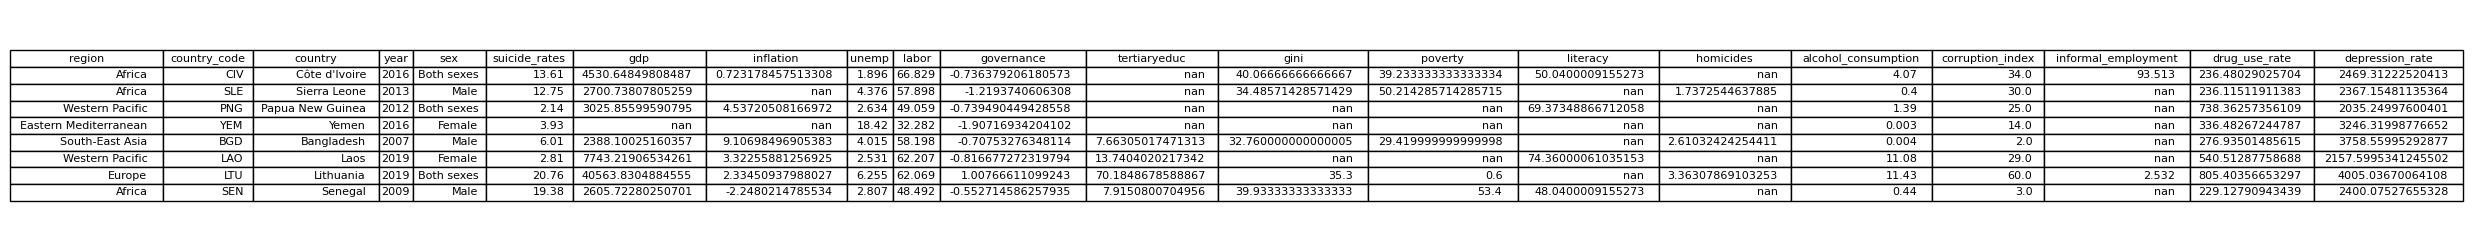

In [11]:
import matplotlib.pyplot as plt

# Selecciona muestra aleatoria
df_sample = super_df.sample(8, random_state=42)

# Crear figura
fig, ax = plt.subplots(figsize=(14, 3))
ax.axis('off')

table = ax.table(
    cellText=df_sample.values,
    colLabels=df_sample.columns,
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(8)
table.auto_set_column_width(col=list(range(len(df_sample.columns))))

plt.savefig("super_df_sample.png", bbox_inches='tight', dpi=300)
plt.show()

In [12]:
super_df.to_parquet(
    "processed_data/super_df.parquet",
    index=False
)

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12210 entries, 0 to 12209
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   region         12210 non-null  str    
 1   country_code   12210 non-null  str    
 2   country        12210 non-null  str    
 3   year           12210 non-null  int64  
 4   sex            12210 non-null  str    
 5   suicide_rates  12210 non-null  float64
dtypes: float64(1), int64(1), str(4)
memory usage: 907.3 KB


In [14]:
df['sex'].nunique()

3